## Exploring computer vision and machine learning methods for detecting and tracking atmospheric storm structures in NASA JunoCam imagery.

## Project question

Can computer vision identify and characterize visually distinct storm-like
structures in images of Jupiter's atmosphere?

The initial goal is not to forecast Jupiter's weather. Instead, this project
will build a reproducible pipeline that detects candidate vortices, measures
their visual properties, and groups similar atmospheric structures.

Later versions may attempt to match storms across observations and estimate
their movement over time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

In [2]:
IMAGE_DIR = Path("data/raw")

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

for path in image_paths:
    print(path.name)

jupyter_001.jpg
jupyter_002.jpg
jupyter_003.jpg
jupyter_004.jpg
jupyter_005.jpg


In [7]:
image = Image.open(image_paths[0]).convert("RGB")
image_array = np.array(image)

print("PIL image size:", image.size)
print("NumPy shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum value:", image_array.min())
print("Maximum value:", image_array.max())

PIL image size: (1920, 1080)
NumPy shape: (1080, 1920, 3)
Data type: uint8
Minimum value: 0
Maximum value: 255


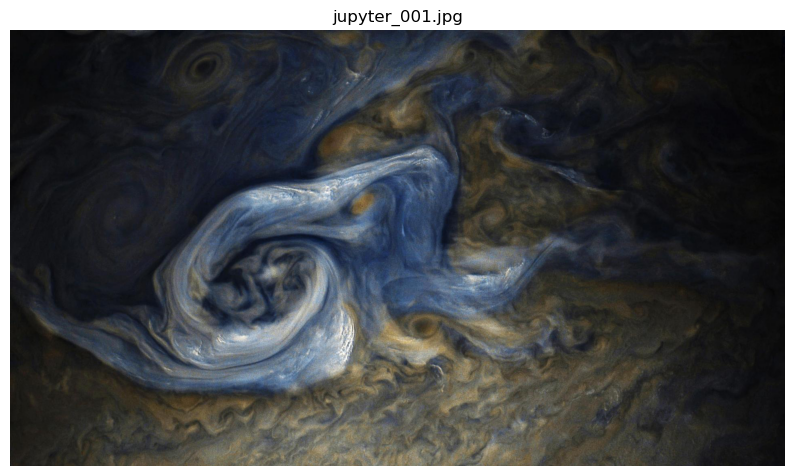

In [10]:
plt.figure(figsize=(10, 7))
plt.imshow(image_array)
plt.title(image_paths[0].name)
plt.axis("off")
plt.show()

In [11]:
height, width, channels = image_array.shape

locations = {
    "top-left": (0, 0),
    "centre": (height // 2, width // 2),
    "bottom-right": (height - 1, width - 1),
}

for name, (row, column) in locations.items():
    print(name, image_array[row, column])

top-left [11 11 11]
centre [30 54 90]
bottom-right [10 10 12]


In [12]:
records = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    arr = np.array(img)

    height, width, channels = arr.shape

    records.append({
        "file": path.name,
        "width": width,
        "height": height,
        "channels": channels,
        "pixel_locations": height * width,
        "stored_values": height * width * channels,
        "mean_red": arr[:, :, 0].mean(),
        "mean_green": arr[:, :, 1].mean(),
        "mean_blue": arr[:, :, 2].mean(),
    })

image_summary = pd.DataFrame(records)
image_summary

,file,width,height,channels,pixel_locations,stored_values,mean_red,mean_green,mean_blue
0,jupyter_001.jpg,1920,1080,3,2073600,6220800,51.227679,53.623375,55.835138
1,jupyter_002.jpg,1600,1200,3,1920000,5760000,96.687392,75.889981,42.627366
2,jupyter_003.jpg,1184,1920,3,2273280,6819840,151.987731,118.540022,89.497862
3,jupyter_004.jpg,1024,1024,3,1048576,3145728,116.758655,120.848140,120.743858
4,jupyter_005.jpg,1024,1024,3,1048576,3145728,72.675673,84.071597,92.836431


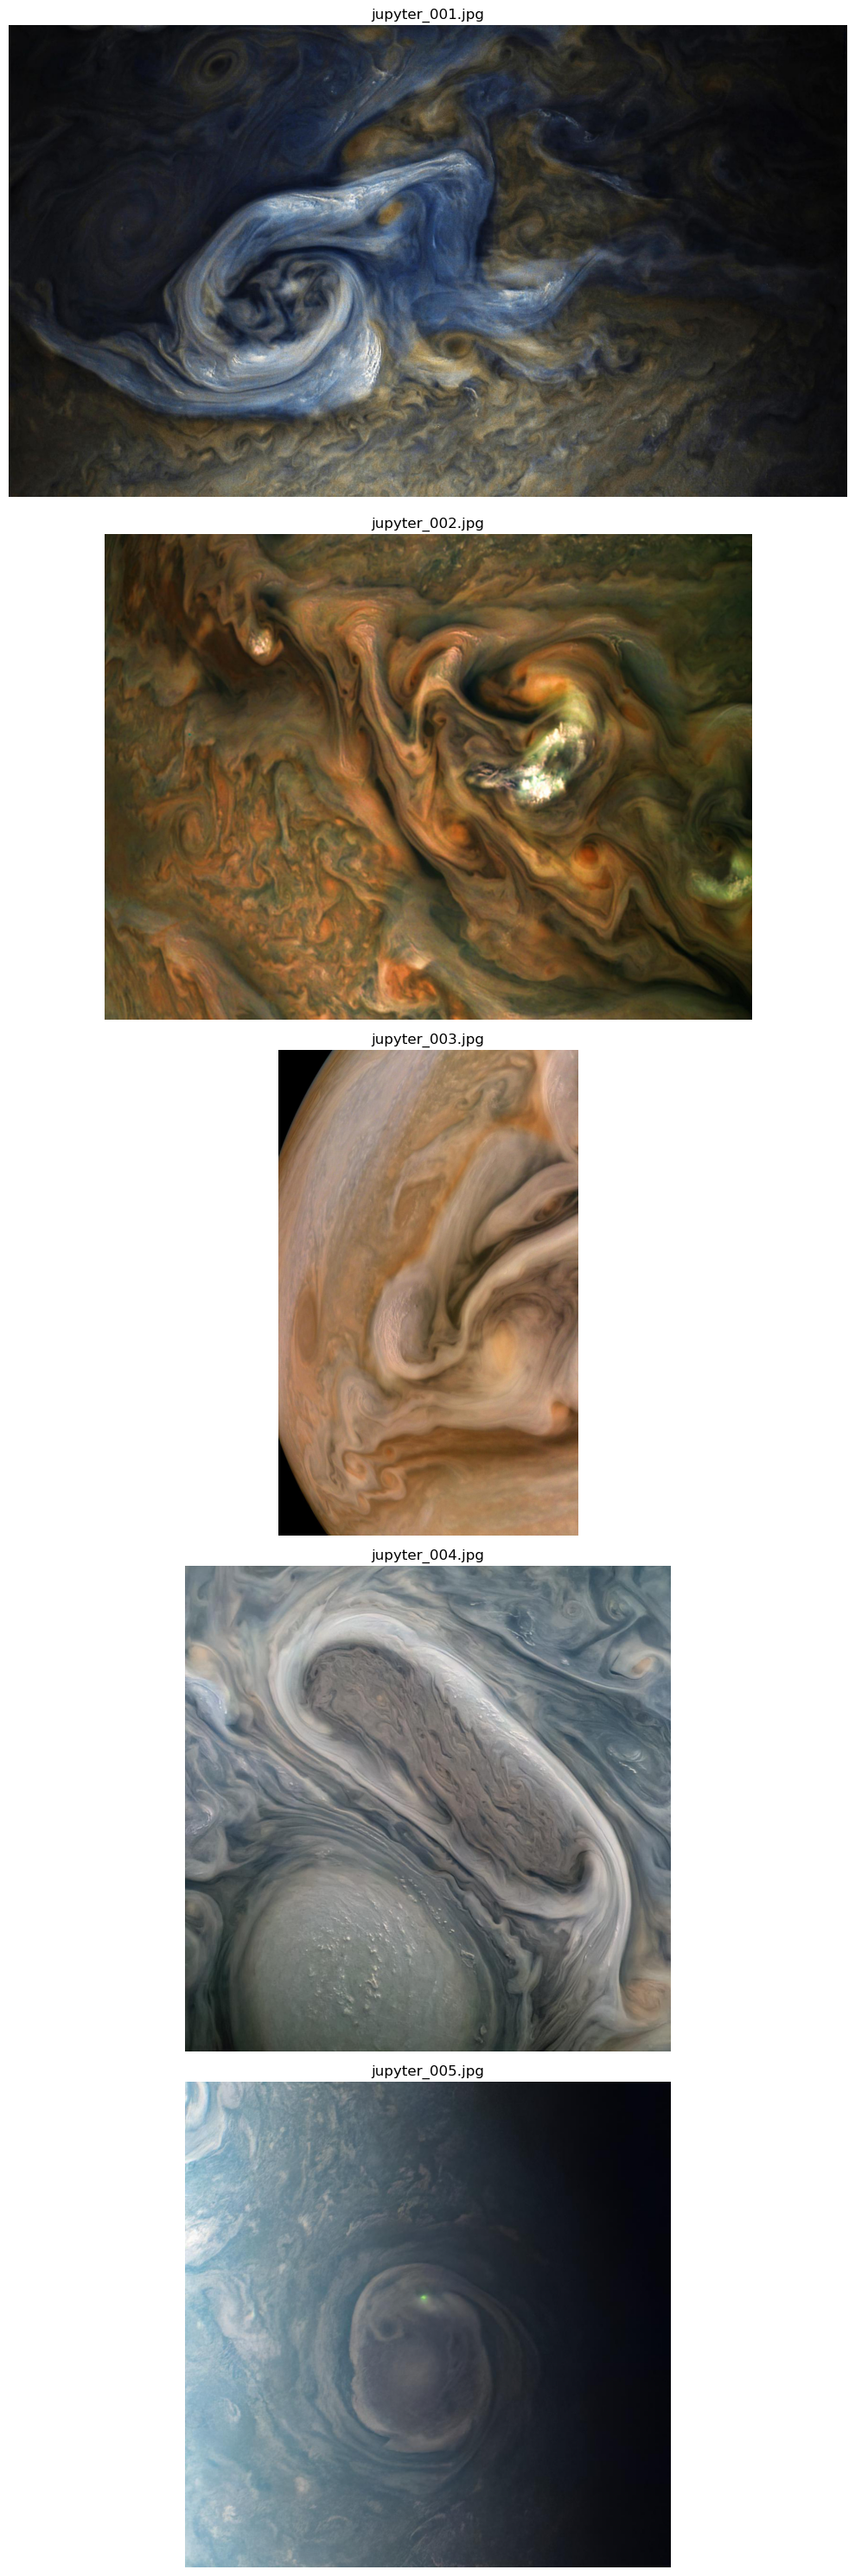

In [13]:
fig, axes = plt.subplots(
    nrows=len(image_paths),
    ncols=1,
    figsize=(10, 6 * len(image_paths))
)

for ax, path in zip(axes, image_paths):
    img = Image.open(path).convert("RGB")

    ax.imshow(img)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

Original shape: (1080, 1920, 3)
Resized shape: (256, 256, 3)


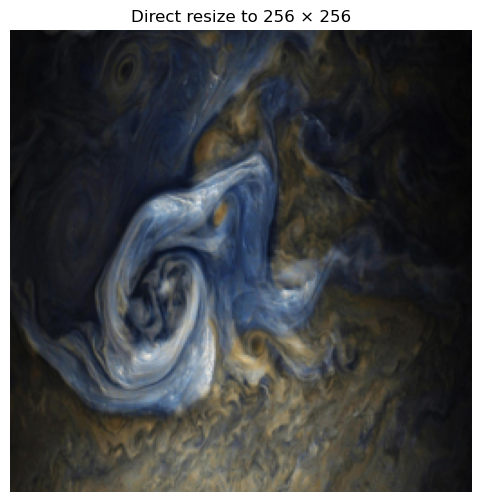

In [14]:
resized_image = image.resize((256, 256))
resized_array = np.array(resized_image)

print("Original shape:", image_array.shape)
print("Resized shape:", resized_array.shape)

plt.figure(figsize=(6, 6))
plt.imshow(resized_array)
plt.title("Direct resize to 256 × 256")
plt.axis("off")
plt.show()